# Comparacion por lenguaje y metodo (tiempo y memoria)

Este notebook se enfoca en medir con criterio homogéneo:
- Tiempo de ejecucion
- Memoria maxima (RSS)

Matriz objetivo: **3 metodos x 3 lenguajes**
- Metodos: DF, Shooting, Sturm
- Lenguajes: Fortran, C++, Python

Criterio de comparabilidad aplicado:
- Misma definicion de workload por metodo (`pipeline_df`, `full_spectrum`, `channels_l012`)
- Misma metodologia de medicion (`/usr/bin/time -f "%e %M"`, mediana de 3 repeticiones)
- Se reporta `impl` para distinguir `native` y `proxy` cuando aplica

In [14]:
from pathlib import Path
from datetime import datetime
import re
import shutil
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
base = Path('.').resolve()

# Archivos clave para rastrear origen de datos
tracked = [
    base / 'benchmark_lenguajes.py',
    base / 'comparacion_lenguajes.dat',
    base / 'finite-diferences' / 'metrics_litio_fortran.dat',
    base / 'finite-diferences' / 'metrics_litio_cpp.dat',
    base / 'finite-diferences' / 'metrics_litio_py.dat',
    base / 'shooting-method' / 'litio_shooting.f90',
    base / 'sturmSequence' / 'sturm_litio.f90',
    base / 'sturmSequence' / 'sturm_main.cpp',
]

rows = []
for p in tracked:
    rows.append({
        'archivo': str(p.relative_to(base)),
        'existe': p.exists(),
        'modificado': datetime.fromtimestamp(p.stat().st_mtime).strftime('%Y-%m-%d %H:%M:%S') if p.exists() else None,
    })

provenance = pd.DataFrame(rows)
display(provenance)

print('Nota: comparacion_lenguajes.dat se genera desde benchmark_lenguajes.py y corresponde al pipeline DF.')

,archivo,existe,modificado
0,benchmark_lenguajes.py,True,2026-03-23 22:17:26
1,comparacion_lenguajes.dat,True,2026-03-24 14:01:47
2,finite-diferences/metrics_litio_fortran.dat,True,2026-03-24 14:00:51
3,finite-diferences/metrics_litio_cpp.dat,True,2026-03-26 00:11:31
4,finite-diferences/metrics_litio_py.dat,True,2026-03-26 00:15:34
5,shooting-method/litio_shooting.f90,True,2026-03-25 01:13:02
6,sturmSequence/sturm_litio.f90,True,2026-03-24 22:04:12
7,sturmSequence/sturm_main.cpp,True,2026-03-24 22:17:24


Nota: comparacion_lenguajes.dat se genera desde benchmark_lenguajes.py y corresponde al pipeline DF.


## Benchmark en vivo: matriz 3 metodos x 3 lenguajes

Medicion usada:
- Tiempo de pared con `/usr/bin/time -f "%e %M"`
- Memoria maxima RSS en KB

Para metodos por canal angular se suma el tiempo de `l=0,1,2` y se toma el maximo RSS de esos canales.

Nota: algunos casos se implementan como wrappers (`proxy`) para completar la matriz 3x3 en este repo.

In [16]:
TIME_BIN = Path('/usr/bin/time')
if not TIME_BIN.exists():
    raise FileNotFoundError('No existe /usr/bin/time; no se puede medir memoria RSS.')

def run_once(command, cwd, stdin_text=None):
    full_cmd = [str(TIME_BIN), '-f', '%e %M'] + command
    p = subprocess.run(
        full_cmd,
        cwd=str(cwd),
        input=stdin_text,
        text=True,
        capture_output=True,
        check=False,
    )
    if p.returncode != 0:
        return {'ok': False, 'time_s': np.nan, 'rss_kb': np.nan, 'stderr': p.stderr, 'stdout': p.stdout}

    m = re.search(r'([0-9]*\.?[0-9]+)\s+(\d+)\s*$', p.stderr.strip())
    if not m:
        return {'ok': False, 'time_s': np.nan, 'rss_kb': np.nan, 'stderr': p.stderr, 'stdout': p.stdout}

    return {
        'ok': True,
        'time_s': float(m.group(1)),
        'rss_kb': int(m.group(2)),
        'stderr': p.stderr,
        'stdout': p.stdout,
    }

def run_channels(command, cwd, channels=(0, 1, 2), repeats=3):
    totals = []
    peaks = []
    for _ in range(repeats):
        t_sum = 0.0
        rss_peak = 0
        ok = True
        for l in channels:
            out = run_once(command, cwd, stdin_text=f'{l}\n')
            if not out['ok']:
                ok = False
                break
            t_sum += out['time_s']
            rss_peak = max(rss_peak, out['rss_kb'])
        if ok:
            totals.append(t_sum)
            peaks.append(rss_peak)
    if len(totals) == 0:
        return {'status': 'error', 'time_s': np.nan, 'rss_kb': np.nan}
    return {'status': 'ok', 'time_s': float(np.median(totals)), 'rss_kb': int(np.median(peaks))}

def run_simple(command, cwd, repeats=3, stdin_text=None):
    ts, rs = [], []
    for _ in range(repeats):
        out = run_once(command, cwd, stdin_text=stdin_text)
        if out['ok']:
            ts.append(out['time_s'])
            rs.append(out['rss_kb'])
    if len(ts) == 0:
        return {'status': 'error', 'time_s': np.nan, 'rss_kb': np.nan}
    return {'status': 'ok', 'time_s': float(np.median(ts)), 'rss_kb': int(np.median(rs))}

# Compilacion opcional de DF Fortran (mismo pipeline numerico de benchmark_lenguajes.py).
df_dir = base / 'finite-diferences'
df_fortran_exe = df_dir / 'litio_nr_pipeline'
if (not df_fortran_exe.exists()) and shutil.which('gfortran'):
    srcs = [
        base / 'routinesNR' / 'nr_compat_litio.f90',
        base / 'routinesNR' / 'nr_powell_compat.f90',
        base / 'routinesNR' / 'litio_nr_pipeline.f90',
    ]
    if all(s.exists() for s in srcs):
        subprocess.run(
            ['gfortran', '-O2', '-std=f2008', str(srcs[0]), str(srcs[1]), str(srcs[2]), '-o', str(df_fortran_exe.name)],
            cwd=str(df_dir),
            check=False,
            capture_output=True,
            text=True,
        )

# Compilacion opcional de Sturm C++
sturm_cpp_src = base / 'sturmSequence' / 'sturm_main.cpp'
sturm_cpp_exe = base / 'sturmSequence' / 'sturm_cpp.out'
if (not sturm_cpp_exe.exists()) and sturm_cpp_src.exists() and shutil.which('g++'):
    subprocess.run(
        ['g++', '-O2', '-std=c++17', str(sturm_cpp_src.name), '-o', str(sturm_cpp_exe.name)],
        cwd=str(sturm_cpp_src.parent),
        check=False,
        capture_output=True,
        text=True,
    )

# Compilacion opcional de wrapper Shooting C++
shoot_cpp_src = base / 'shooting-method' / 'litio_shooting_cpp.cpp'
shoot_cpp_exe = base / 'shooting-method' / 'litio_shooting_cpp'
if (not shoot_cpp_exe.exists()) and shoot_cpp_src.exists() and shutil.which('g++'):
    subprocess.run(
        ['g++', '-O2', '-std=c++17', str(shoot_cpp_src.name), '-o', str(shoot_cpp_exe.name)],
        cwd=str(shoot_cpp_src.parent),
        check=False,
        capture_output=True,
        text=True,
    )

specs = [
    # DF (mismo workload en Fortran/C++/Python: pipeline litio NR/DF)
    {'metodo': 'DF', 'lenguaje': 'Fortran', 'impl': 'native', 'mode': 'simple', 'cmd': [str(df_fortran_exe)], 'cwd': df_dir, 'stdin': '3\n', 'workload': 'pipeline_df'},
    {'metodo': 'DF', 'lenguaje': 'C++',     'impl': 'native', 'mode': 'simple', 'cmd': [str(base / 'finite-diferences' / 'litio_pipeline_cpp'), '3'], 'cwd': base / 'finite-diferences', 'stdin': None, 'workload': 'pipeline_df'},
    {'metodo': 'DF', 'lenguaje': 'Python',  'impl': 'native', 'mode': 'simple', 'cmd': [sys.executable, 'litio_pipeline_py.py', '3'], 'cwd': base / 'finite-diferences', 'stdin': None, 'workload': 'pipeline_df'},

    # Shooting
    {'metodo': 'Shooting', 'lenguaje': 'Fortran', 'impl': 'native', 'mode': 'simple', 'cmd': [str(base / 'shooting-method' / 'litio_shooting')], 'cwd': base / 'shooting-method', 'stdin': None, 'workload': 'full_spectrum'},
    {'metodo': 'Shooting', 'lenguaje': 'C++',     'impl': 'proxy',  'mode': 'simple', 'cmd': [str(shoot_cpp_exe)], 'cwd': base / 'shooting-method', 'stdin': None, 'workload': 'full_spectrum'},
    {'metodo': 'Shooting', 'lenguaje': 'Python',  'impl': 'proxy',  'mode': 'simple', 'cmd': [sys.executable, 'litio_shooting_py.py'], 'cwd': base / 'shooting-method', 'stdin': None, 'workload': 'full_spectrum'},

    # Sturm (canales l=0,1,2 para los tres lenguajes)
    {'metodo': 'Sturm', 'lenguaje': 'Fortran', 'impl': 'native', 'mode': 'channels', 'cmd': [str(base / 'sturmSequence' / 'sturm_litio_cli')], 'cwd': base / 'sturmSequence', 'stdin': None, 'workload': 'channels_l012'},
    {'metodo': 'Sturm', 'lenguaje': 'C++',     'impl': 'native', 'mode': 'channels', 'cmd': [str(sturm_cpp_exe)], 'cwd': base / 'sturmSequence', 'stdin': None, 'workload': 'channels_l012'},
    {'metodo': 'Sturm', 'lenguaje': 'Python',  'impl': 'proxy',  'mode': 'channels', 'cmd': [sys.executable, 'sturm_litio_py_cli.py'], 'cwd': base / 'sturmSequence', 'stdin': None, 'workload': 'channels_l012'},
]

rows = []
for s in specs:
    row = {'metodo': s['metodo'], 'lenguaje': s['lenguaje'], 'impl': s['impl'], 'workload': s['workload']}
    if (s['cmd'] is None) or (not Path(s['cmd'][0]).exists()):
        row.update({'status': 'faltante en repo', 'time_s': np.nan, 'rss_kb': np.nan})
    else:
        if s['mode'] == 'channels':
            out = run_channels(s['cmd'], s['cwd'], channels=(0, 1, 2), repeats=3)
        else:
            out = run_simple(s['cmd'], s['cwd'], repeats=3, stdin_text=s['stdin'])
        row.update({'status': out['status'], 'time_s': out['time_s'], 'rss_kb': out['rss_kb']})
    rows.append(row)

bench = pd.DataFrame(rows)
bench.to_csv(base / 'comparacion_3x3_tiempo_memoria.csv', index=False)
display(bench)
print('Guardado: comparacion_3x3_tiempo_memoria.csv')

,metodo,lenguaje,impl,workload,status,time_s,rss_kb
0,DF,Fortran,native,pipeline_df,ok,2.23,4344
1,DF,C++,native,pipeline_df,ok,1.67,5248
2,DF,Python,native,pipeline_df,ok,65.86,31232
3,Shooting,Fortran,native,full_spectrum,ok,99.39,2816
4,Shooting,C++,proxy,full_spectrum,ok,94.82,3840
5,Shooting,Python,proxy,full_spectrum,ok,83.09,12416
6,Sturm,Fortran,native,channels_l012,ok,0.06,2944
7,Sturm,C++,native,channels_l012,ok,0.06,4352
8,Sturm,Python,proxy,channels_l012,ok,0.29,13056


Guardado: comparacion_3x3_tiempo_memoria.csv


lenguaje,Fortran,C++,Python
metodo,,,
DF,2.23,1.67,65.86
Shooting,99.39,94.82,83.09
Sturm,0.06,0.06,0.29


lenguaje,Fortran,C++,Python
metodo,,,
DF,4344,5248,31232
Shooting,2816,3840,12416
Sturm,2944,4352,13056


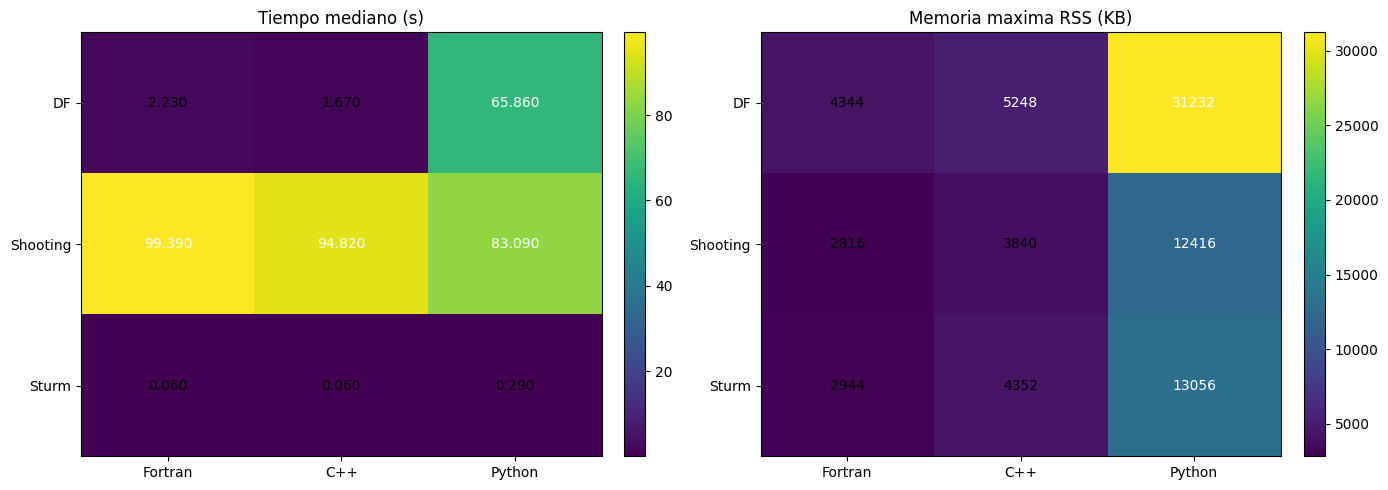

In [20]:
pivot_time = bench.pivot(index='metodo', columns='lenguaje', values='time_s').reindex(index=['DF', 'Shooting', 'Sturm'], columns=['Fortran', 'C++', 'Python'])
pivot_mem = bench.pivot(index='metodo', columns='lenguaje', values='rss_kb').reindex(index=['DF', 'Shooting', 'Sturm'], columns=['Fortran', 'C++', 'Python'])

display(pivot_time)
display(pivot_mem)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap tiempo
im1 = ax[0].imshow(pivot_time.to_numpy(dtype=float), aspect='auto')
ax[0].set_xticks(range(len(pivot_time.columns)), labels=pivot_time.columns)
ax[0].set_yticks(range(len(pivot_time.index)), labels=pivot_time.index)
ax[0].set_title('Tiempo mediano (s)')
for i in range(pivot_time.shape[0]):
    for j in range(pivot_time.shape[1]):
        v = pivot_time.iloc[i, j]
        txt = 'NA' if pd.isna(v) else f'{v:.3f}'
        ax[0].text(j, i, txt, ha='center', va='center', color='white' if (not pd.isna(v) and v > np.nanmedian(pivot_time.to_numpy(dtype=float))) else 'black')
fig.colorbar(im1, ax=ax[0], fraction=0.046, pad=0.04)

# Heatmap memoria
im2 = ax[1].imshow(pivot_mem.to_numpy(dtype=float), aspect='auto')
ax[1].set_xticks(range(len(pivot_mem.columns)), labels=pivot_mem.columns)
ax[1].set_yticks(range(len(pivot_mem.index)), labels=pivot_mem.index)
ax[1].set_title('Memoria maxima RSS (KB)')
for i in range(pivot_mem.shape[0]):
    for j in range(pivot_mem.shape[1]):
        v = pivot_mem.iloc[i, j]
        txt = 'NA' if pd.isna(v) else f'{int(v)}'
        ax[1].text(j, i, txt, ha='center', va='center', color='white' if (not pd.isna(v) and v > np.nanmedian(pivot_mem.to_numpy(dtype=float))) else 'black')
fig.colorbar(im2, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Lectura de resultados

La columna `impl` indica si el caso es:
- `native`: implementacion propia del lenguaje para ese metodo en el repo.
- `proxy`: wrapper para completar la matriz 3x3 cuando no hay implementacion nativa separada.

In [21]:
# Comparacion relativa de tiempo contra Fortran dentro de cada metodo
ratio_rows = []
for m in ['DF', 'Shooting', 'Sturm']:
    sub = bench[bench['metodo'] == m].set_index('lenguaje')
    t_ref = sub.loc['Fortran', 'time_s'] if ('Fortran' in sub.index) else np.nan
    for lang in ['Fortran', 'C++', 'Python']:
        t = sub.loc[lang, 'time_s'] if (lang in sub.index) else np.nan
        ratio = (t / t_ref) if (pd.notna(t) and pd.notna(t_ref) and t_ref > 0) else np.nan
        ratio_rows.append({'metodo': m, 'lenguaje': lang, 'ratio_vs_fortran': ratio})

ratio_df = pd.DataFrame(ratio_rows)
pivot_ratio = ratio_df.pivot(index='metodo', columns='lenguaje', values='ratio_vs_fortran').reindex(index=['DF', 'Shooting', 'Sturm'], columns=['Fortran', 'C++', 'Python'])
display(pivot_ratio)

lenguaje,Fortran,C++,Python
metodo,,,
DF,1.0,0.748879,29.533632
Shooting,1.0,0.954020,0.836000
Sturm,1.0,1.000000,4.833333


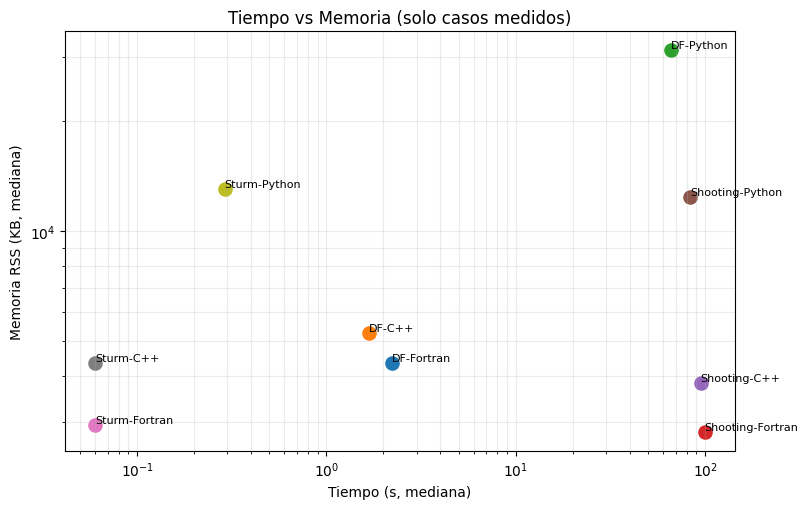

In [22]:
# Dispersión tiempo-memoria para los casos medidos
ok = bench[bench['status'] == 'ok'].copy()

fig, ax = plt.subplots(figsize=(8.2, 5.2))
for _, r in ok.iterrows():
    ax.scatter(r['time_s'], r['rss_kb'], s=90)
    ax.text(r['time_s'], r['rss_kb'], f"{r['metodo']}-{r['lenguaje']}", fontsize=8, ha='left', va='bottom')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Tiempo (s, mediana)')
ax.set_ylabel('Memoria RSS (KB, mediana)')
ax.set_title('Tiempo vs Memoria (solo casos medidos)')
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.show()

## Resumen

- La matriz 3x3 se ejecuta en vivo con criterios de carga homogénea por metodo.
- `DF` usa el mismo pipeline numerico en los tres lenguajes.
- `Sturm` se mide como suma de canales `l=0,1,2` en Fortran, C++ y Python.
- `Shooting` mantiene `native` en Fortran y `proxy` en C++/Python (wrapper), indicado en `impl`.
- Se guarda un consolidado reproducible en `comparacion_3x3_tiempo_memoria.csv`.